India Data Analyst Job Market Analysis

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

df= pd.read_csv('../data/naukri_jobs_with_skills.csv')
print(f"Total jobs loaded: {len(df)}")
df.head(3)

Total jobs loaded: 397


,job_id,Title,Company,Experience,Location,Description,Posted_Date,Skills_Listed,Job_URL,date_scraped,...,GenAI,Deep Learning,NLP,Data Visualization,Hadoop,Airflow,Docker,BigQuery,SAS,total_skills_found
0,21225014173,Data Analyst,Capgemini,4-9 Yrs,"Hybrid - Chennai, Delhi / NCR, Mumbai (All Areas)",Required Skills & Qualifications: . Bachelors ...,3+ weeks ago,"Power Bi, Data Analysis, Data Visualization, T...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,1,0,0,0,0,0,5
1,221025507695,Data Analyst,Snapdeal,1-6 Yrs,Gurugram,Providing technical expertise in data storage ...,3+ weeks ago,"master data, python, metadata, data analysis, ...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,0,0,0,0,0,0,1
2,200326006395,Data Analyst,Kiya.ai,3-7 Yrs,"Hybrid - Bengaluru, Mumbai (All Areas)",Must possess the ability to research and resol...,4 days ago,"Power Bi, Data Analysis, Tableau, SQL, Capital...",https://www.naukri.com/job-listings-data-analy...,2026-06-22,...,0,0,0,0,0,0,0,0,0,3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_id              397 non-null    int64
 1   Title               397 non-null    str  
 2   Company             397 non-null    str  
 3   Experience          389 non-null    str  
 4   Location            397 non-null    str  
 5   Description         390 non-null    str  
 6   Posted_Date         397 non-null    str  
 7   Skills_Listed       390 non-null    str  
 8   Job_URL             397 non-null    str  
 9   date_scraped        397 non-null    str  
 10  SQL                 397 non-null    int64
 11  Python              397 non-null    int64
 12  Excel               397 non-null    int64
 13  Power BI            397 non-null    int64
 14  Tableau             397 non-null    int64
 15  AWS                 397 non-null    int64
 16  Azure               397 non-null    int64
 17  GCP     

Data Cleaning 

In [4]:
print(df[['Title', 'Company', 'Location', 'Experience']].isna().sum())
# Drop rows where Title or Company is missing — these are unusable
df = df.dropna(subset=['Title', 'Company'])
print(f"Jobs after dropping missing Title/Company: {len(df)}")

Title         0
Company       0
Location      0
Experience    8
dtype: int64
Jobs after dropping missing Title/Company: 397


In [5]:
# Cleaning experience column to extract min experience in years


import re

def extract_min_experience(exp_text):
    if pd.isna(exp_text) or exp_text == 'N/A':
        return np.nan
    match = re.search(r'(\d+)', str(exp_text))
    if match:
        return int(match.group(1))
    return np.nan

df['min_experience'] = df['Experience'].apply(extract_min_experience)
df[['Experience', 'min_experience']].head(10)


# Create experience level buckets
def experience_bucket(years):
    if pd.isna(years):
        return 'Unknown'
    elif years == 0:
        return 'Fresher (0 yrs)'
    elif years <= 2:
        return 'Junior (0-2 yrs)'
    elif years <= 5:
        return 'Mid (3-5 yrs)'
    else:
        return 'Senior (5+ yrs)'

df['experience_level'] = df['min_experience'].apply(experience_bucket)
df['experience_level'].value_counts()



experience_level
Junior (0-2 yrs)    142
Mid (3-5 yrs)       134
Fresher (0 yrs)      78
Senior (5+ yrs)      35
Unknown               8
Name: count, dtype: int64

In [6]:
# Clean Posted_Date into recency buckets
def clean_posted_date(date_text):
    date_text = str(date_text).lower()
    if 'today' in date_text or 'few hours' in date_text:
        return 'Today'
    elif 'day' in date_text:
        return 'This Week'
    elif '1 week' in date_text:
        return '1-2 Weeks'
    elif '2 week' in date_text:
        return '2-3 Weeks'
    elif '3+' in date_text or '3 week' in date_text:
        return '3+ Weeks'
    else:
        return 'Unknown'

df['recency_bucket'] = df['Posted_Date'].apply(clean_posted_date)
df['recency_bucket'].value_counts()

recency_bucket
3+ Weeks     182
This Week     70
1-2 Weeks     61
Today         39
2-3 Weeks     37
Unknown        8
Name: count, dtype: int64

In [7]:
# Clean Location — split multi-location postings, take primary location
def clean_location(loc_text):
    if pd.isna(loc_text):
        return 'Unknown'
    loc_text = str(loc_text).replace('Hybrid - ', '').strip()
    primary = loc_text.split(',')[0].strip()
    return primary

df['primary_location'] = df['Location'].apply(clean_location)
df['primary_location'].value_counts().head(15)

primary_location
Bengaluru             83
Hyderabad             58
Pune                  39
Gurugram              28
Chennai               25
Mumbai                21
Remote                16
Noida                 16
New Delhi             16
Mumbai (All Areas)    10
Kolkata                8
Pimpri-Chinchwad       3
Jaipur                 3
Coimbatore             3
Navi Mumbai            3
Name: count, dtype: int64

In [8]:
# Consolidate location variants
location_map = {
    'Mumbai (All Areas)': 'Mumbai',
    'Navi Mumbai': 'Mumbai',
    'Pimpri-Chinchwad': 'Pune',
    'Noida': 'Delhi NCR',
    'New Delhi': 'Delhi NCR',
    'Gurugram': 'Delhi NCR',
    'Delhi': 'Delhi NCR',
}

df['primary_location'] = df['primary_location'].replace(location_map)
df['primary_location'].value_counts().head(10)

primary_location
Bengaluru     83
Delhi NCR     60
Hyderabad     58
Pune          42
Mumbai        34
Chennai       25
Remote        16
Kolkata        8
Jaipur         3
Coimbatore     3
Name: count, dtype: int64

Skill Frequency Analysis

In [9]:
skill_columns = [
    'SQL', 'Python', 'Excel', 'Power BI', 'Tableau', 'AWS', 'Azure', 'GCP',
    'Machine Learning', 'Statistics', 'R', 'Spark', 'Git', 'Pandas', 'NumPy',
    'Scikit-learn', 'Looker', 'DAX', 'Snowflake', 'ETL', 'Power Query',
    'GenAI', 'Deep Learning', 'NLP', 'Data Visualization', 'Hadoop',
    'Airflow', 'Docker', 'BigQuery', 'SAS'
]
skill_demand = df[skill_columns].sum().sort_values(ascending=False)
skill_demand_pct = (skill_demand / len(df) * 100).round(1)
skill_summary = pd.DataFrame({
    'job_count': skill_demand,
    'demand_pct': skill_demand_pct
})
print(skill_summary.to_string())


                    job_count  demand_pct
SQL                       143        36.0
Python                    124        31.2
Power BI                  120        30.2
Tableau                    48        12.1
Data Visualization         48        12.1
Excel                      41        10.3
Statistics                 31         7.8
Machine Learning           30         7.6
ETL                        19         4.8
SAS                        17         4.3
GCP                        14         3.5
AWS                         9         2.3
Azure                       8         2.0
Spark                       6         1.5
NLP                         6         1.5
Looker                      6         1.5
Git                         6         1.5
GenAI                       5         1.3
BigQuery                    4         1.0
DAX                         4         1.0
Snowflake                   4         1.0
Hadoop                      3         0.8
Power Query                 2     

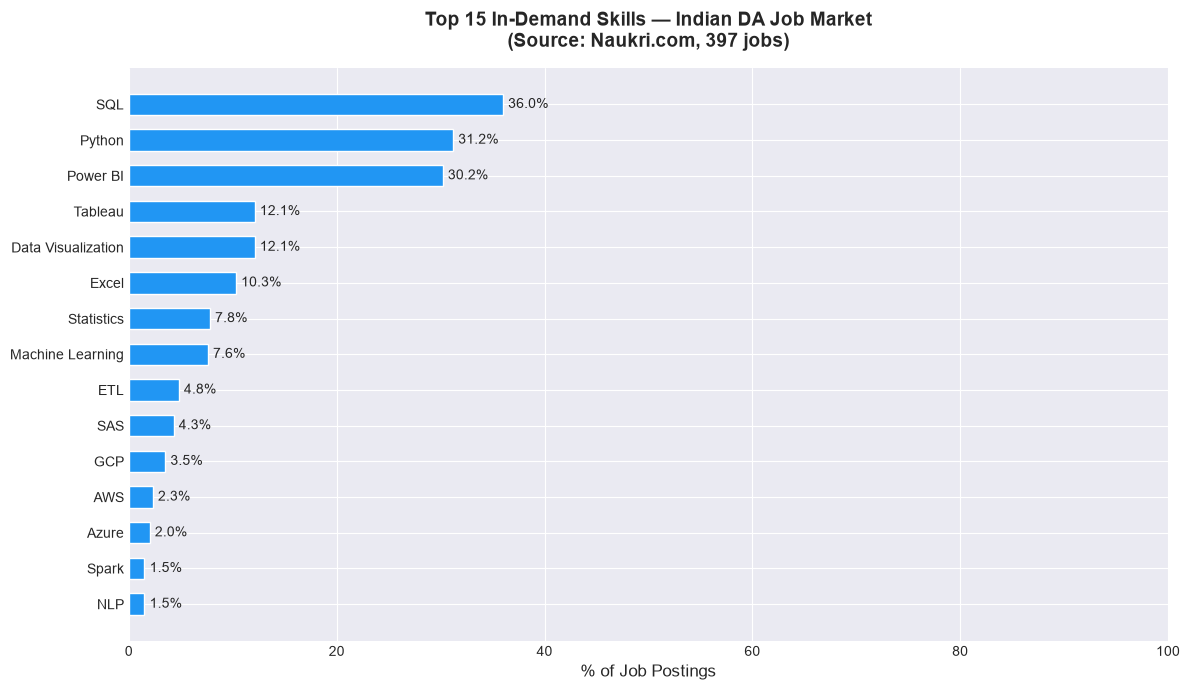

Chart saved.


In [10]:
# Chart 1 — Top 15 Skills by Demand
fig, ax = plt.subplots(figsize=(12, 7))

top_15 = skill_summary.head(15)

bars = ax.barh(
    top_15.index[::-1],
    top_15['demand_pct'][::-1],
    color='#2196F3',
    edgecolor='white',
    height=0.6
)

# Add percentage labels on bars
for bar, pct in zip(bars, top_15['demand_pct'][::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{pct}%',
        va='center',
        fontsize=10
    )

ax.set_xlabel('% of Job Postings', fontsize=12)
ax.set_title('Top 15 In-Demand Skills — Indian DA Job Market\n(Source: Naukri.com, 397 jobs)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/top_skills_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

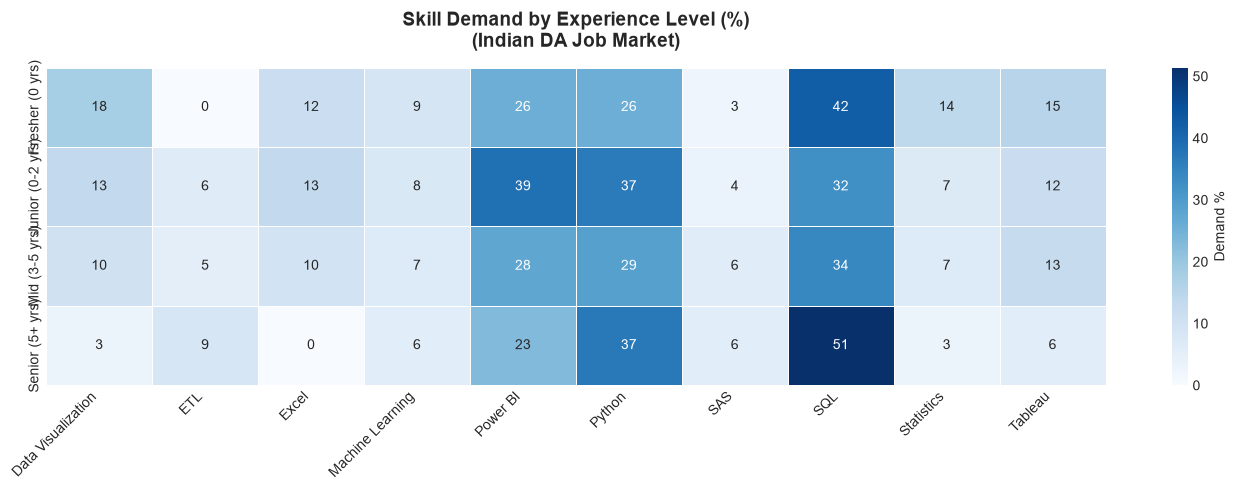

Chart saved.


In [11]:
# Chart 2 — Skill Demand by Experience Level

exp_levels = ['Fresher (0 yrs)', 'Junior (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (5+ yrs)']
top_10_skills = skill_summary.head(10).index.tolist()


exp_skill_data = []
for level in exp_levels:
    level_df = df[df['experience_level'] == level]
    if len(level_df) == 0:
        continue
    for skill in top_10_skills:
        pct = level_df[skill].mean() * 100
        exp_skill_data.append({
            'experience_level': level,
            'skill': skill,
            'demand_pct': round(pct, 1)
        })

exp_skill_df = pd.DataFrame(exp_skill_data)

# Pivot for heatmap
pivot = exp_skill_df.pivot(
    index='experience_level', 
    columns='skill', 
    values='demand_pct'
)
pivot = pivot.reindex(exp_levels)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Demand %'}
)
ax.set_title('Skill Demand by Experience Level (%)\n(Indian DA Job Market)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/skill_by_experience.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

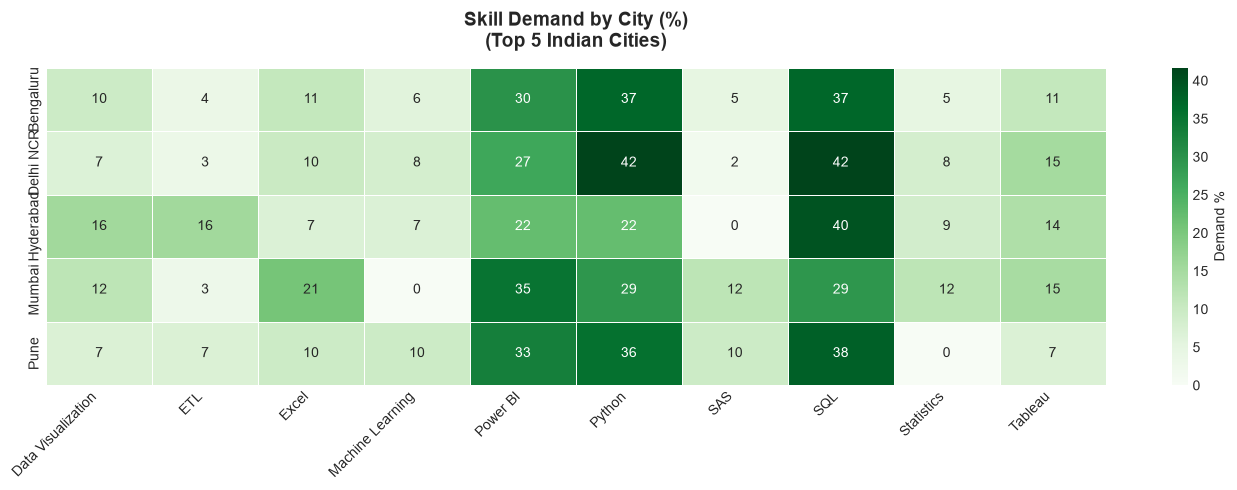

Chart saved.


In [12]:
# Chart 3 — Skill Demand by Top 5 Cities
top_cities = df['primary_location'].value_counts().head(5).index.tolist()
top_10_skills = skill_summary.head(10).index.tolist()

city_skill_data = []
for city in top_cities:
    city_df = df[df['primary_location'] == city]
    for skill in top_10_skills:
        pct = city_df[skill].mean() * 100
        city_skill_data.append({
            'city': city,
            'skill': skill,
            'demand_pct': round(pct, 1)
        })

city_skill_df = pd.DataFrame(city_skill_data)

pivot_city = city_skill_df.pivot(
    index='city',
    columns='skill',
    values='demand_pct'
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_city,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Demand %'}
)
ax.set_title('Skill Demand by City (%)\n(Top 5 Indian Cities)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/skill_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

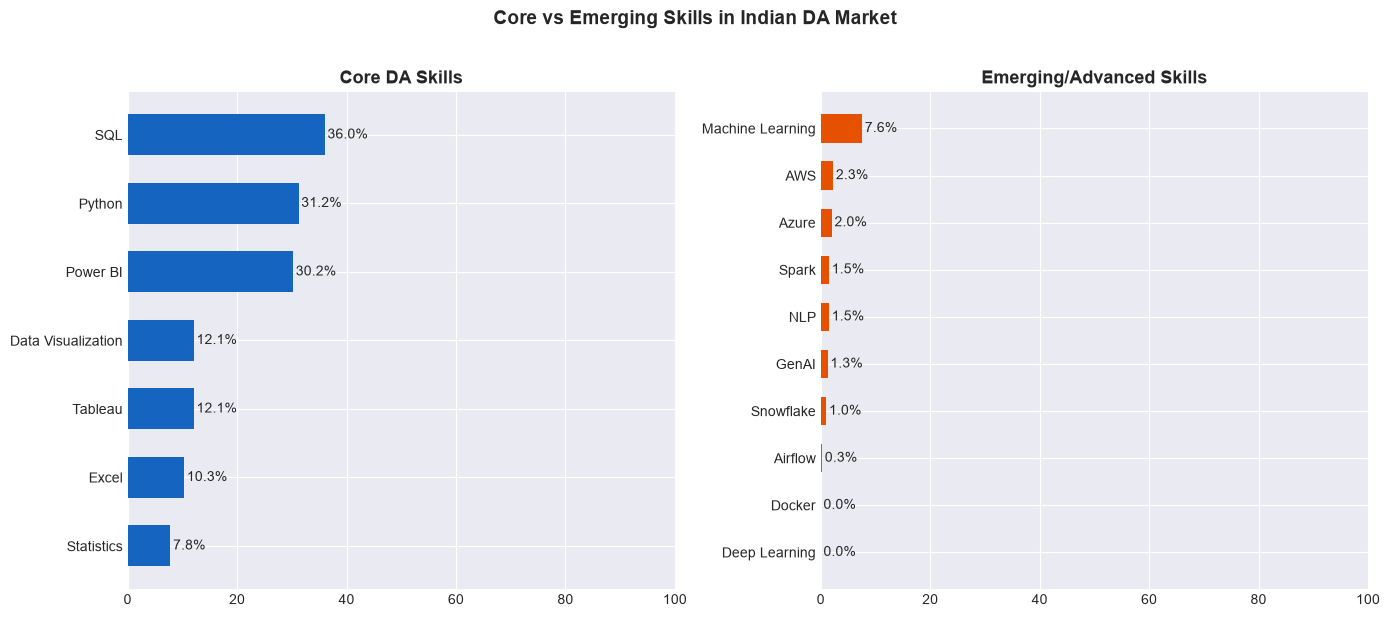

Chart saved.


In [13]:
# Chart 4 — Skills split: Core vs Emerging
core_skills = ['SQL', 'Python', 'Excel', 'Power BI', 'Tableau', 
               'Statistics', 'Data Visualization']
emerging_skills = ['Machine Learning', 'GenAI', 'Deep Learning', 'NLP', 
                   'Spark', 'Airflow', 'Snowflake', 'Docker', 'AWS', 'Azure']

core_avg = df[core_skills].mean().mean() * 100
emerging_avg = df[emerging_skills].mean().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Core skills
core_vals = (df[core_skills].mean() * 100).sort_values(ascending=True)
axes[0].barh(core_vals.index, core_vals.values, color='#1565C0', height=0.6)
for i, v in enumerate(core_vals.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[0].set_title('Core DA Skills', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 100)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Emerging skills
emerging_vals = (df[emerging_skills].mean() * 100).sort_values(ascending=True)
axes[1].barh(emerging_vals.index, emerging_vals.values, color='#E65100', height=0.6)
for i, v in enumerate(emerging_vals.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_title('Emerging/Advanced Skills', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 100)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Core vs Emerging Skills in Indian DA Market', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/core_vs_emerging.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

Co-occurance Analysis

In [14]:
# Cell 1 — Building the co-occurrence matrix
# For each pair of skills, count how many jobs mention both

# Using only top 15 skills for cleaner visualization
top_15_skills = skill_summary.head(15).index.tolist()
skill_matrix = df[top_15_skills]


# When two columns both have 1 in same row, product = 1
co_occurrence = skill_matrix.T.dot(skill_matrix)

# Converting counts to percentages (out of total jobs)
co_occurrence_pct = (co_occurrence / len(df) * 100).round(1)

# Setting diagonal to 0 — a skill co-occurring with itself isn't useful
for i in range(len(co_occurrence_pct)):
    co_occurrence_pct.iat[i, i] = 0

print("Co-occurrence matrix (% of jobs where both skills appear together):")
print(co_occurrence_pct.to_string())

Co-occurrence matrix (% of jobs where both skills appear together):
                     SQL  Python  Power BI  Tableau  Data Visualization  Excel  Statistics  Machine Learning  ETL  SAS  GCP  AWS  Azure  Spark  NLP
SQL                  0.0    13.4      15.1      8.6                 6.8    3.5         3.8               2.5  3.3  1.0  0.5  0.8    1.0    0.5  0.3
Python              13.4     0.0      13.1      5.3                 3.3    3.3         3.5               3.3  1.8  2.8  0.3  0.5    0.8    1.5  0.8
Power BI            15.1    13.1       0.0      8.8                 6.8    6.3         3.3               1.0  1.8  1.5  0.3  1.0    1.3    0.0  0.3
Tableau              8.6     5.3       8.8      0.0                 3.8    2.3         2.0               0.3  1.0  0.3  0.3  1.0    0.0    0.0  0.0
Data Visualization   6.8     3.3       6.8      3.8                 0.0    2.3         2.0               1.0  0.5  0.5  0.0  0.3    0.0    0.0  0.0
Excel                3.5     3.3       6.3  

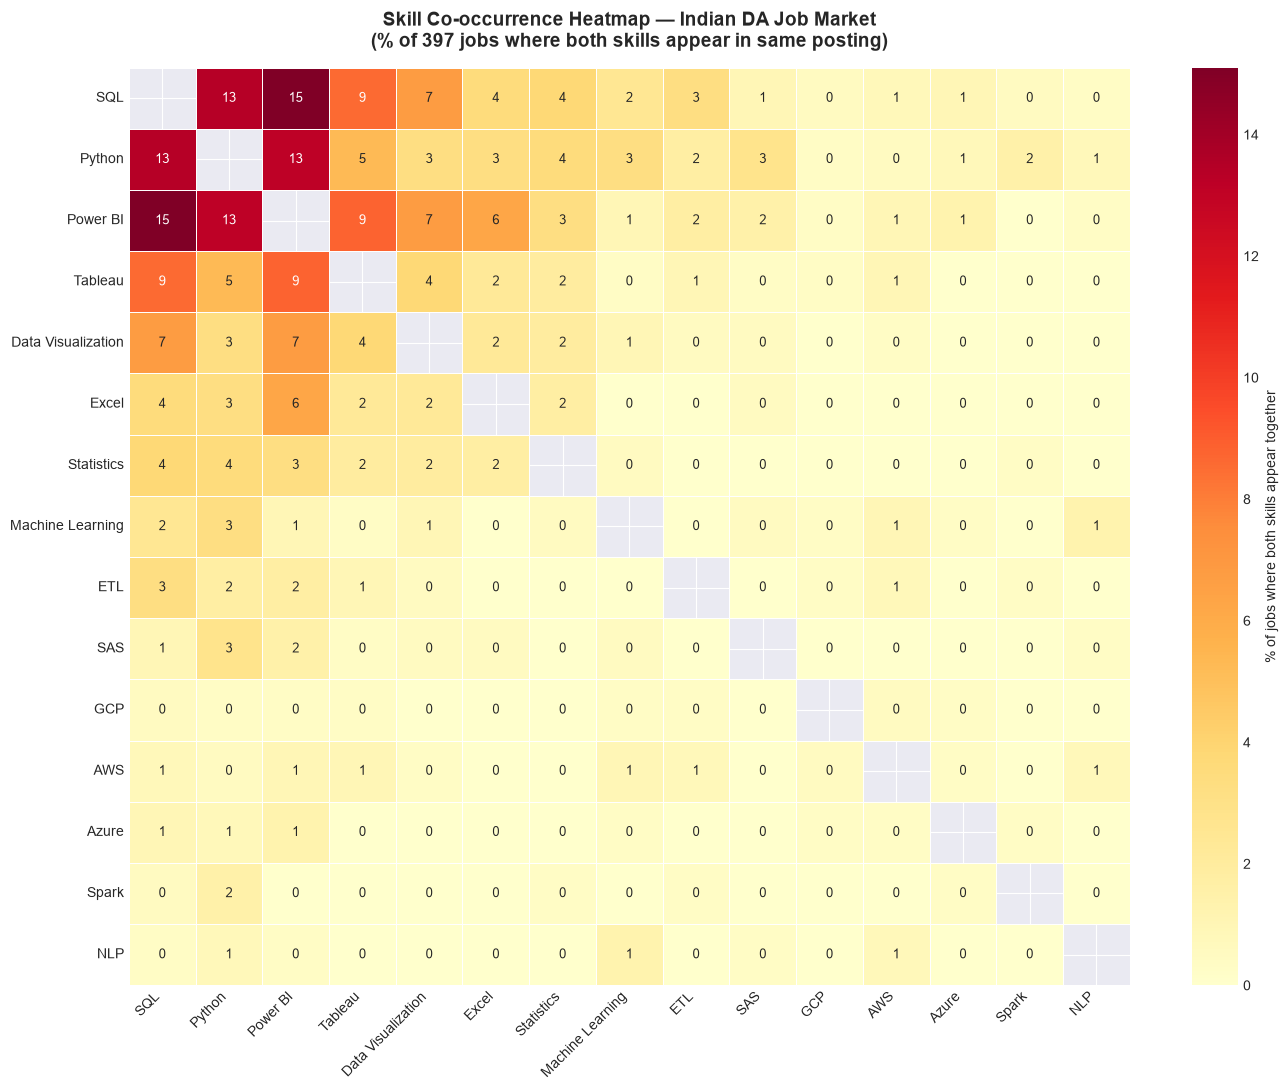

Chart saved.


In [15]:
# Cell 2 — Co-occurrence Heatmap
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.zeros_like(co_occurrence_pct, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    co_occurrence_pct,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    mask=mask,
    cbar_kws={'label': '% of jobs where both skills appear together'},
    annot_kws={'size': 9}
)

ax.set_title(
    'Skill Co-occurrence Heatmap — Indian DA Job Market\n'
    '(% of 397 jobs where both skills appear in same posting)',
    fontsize=14, fontweight='bold', pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../data/skill_cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [16]:
# Cell 3 — Top 15 strongest skill pairs
# Find the most commonly co-occurring pairs

pairs = []
skills = top_15_skills

for i in range(len(skills)):
    for j in range(i+1, len(skills)):  
        skill_a = skills[i]
        skill_b = skills[j]
        count = co_occurrence_pct.loc[skill_a, skill_b]
        pairs.append({
            'Skill A': skill_a,
            'Skill B': skill_b,
            'Co-occurrence %': count,
            'Jobs Together': int(co_occurrence.loc[skill_a, skill_b])
        })

pairs_df = pd.DataFrame(pairs)
pairs_df = pairs_df.sort_values('Co-occurrence %', ascending=False)

print("Top 20 most common skill combinations:")
print(pairs_df.head(20).to_string(index=False))

Top 20 most common skill combinations:
 Skill A            Skill B  Co-occurrence %  Jobs Together
     SQL           Power BI             15.1             60
     SQL             Python             13.4             53
  Python           Power BI             13.1             52
Power BI            Tableau              8.8             35
     SQL            Tableau              8.6             34
     SQL Data Visualization              6.8             27
Power BI Data Visualization              6.8             27
Power BI              Excel              6.3             25
  Python            Tableau              5.3             21
     SQL         Statistics              3.8             15
 Tableau Data Visualization              3.8             15
  Python         Statistics              3.5             14
     SQL              Excel              3.5             14
  Python              Excel              3.3             13
  Python   Machine Learning              3.3             13
 

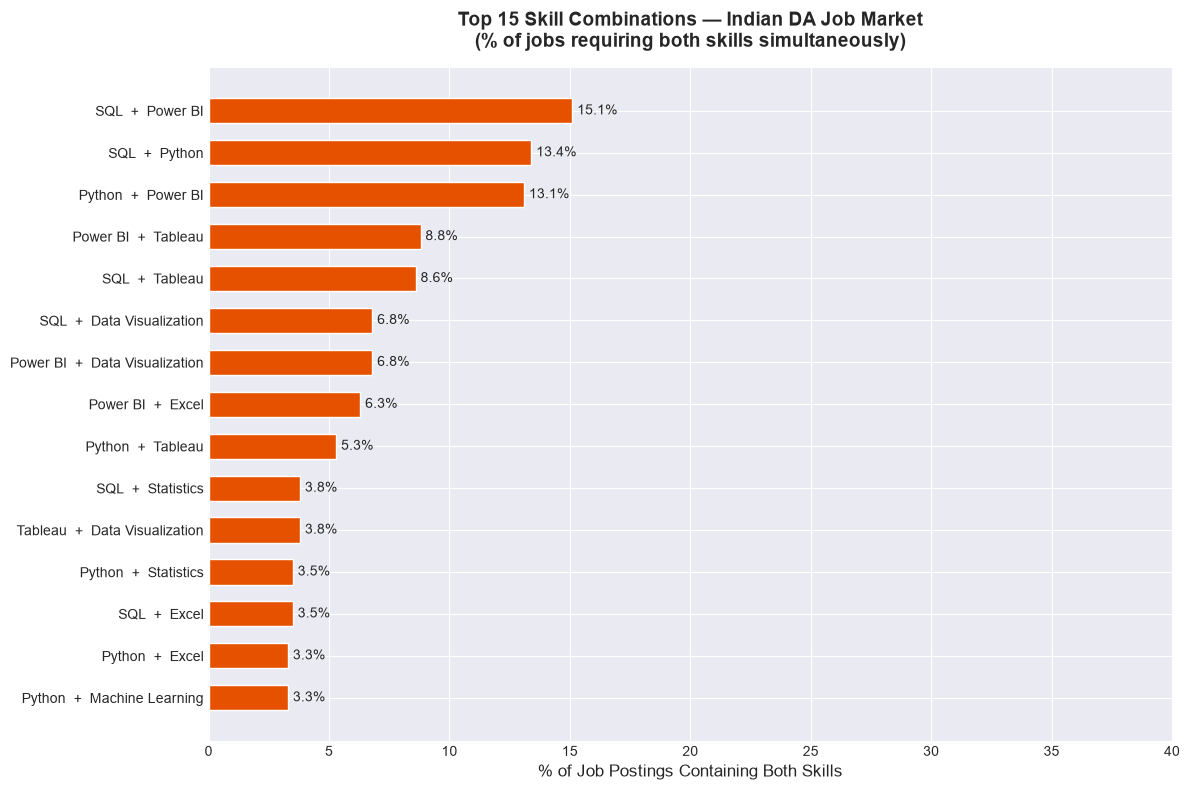

Chart saved.


In [17]:
# Cell 4 — Visualise top skill pairs
fig, ax = plt.subplots(figsize=(12, 8))

top_pairs = pairs_df.head(15).copy()
top_pairs['pair_label'] = top_pairs['Skill A'] + '  +  ' + top_pairs['Skill B']

bars = ax.barh(
    top_pairs['pair_label'][::-1],
    top_pairs['Co-occurrence %'][::-1],
    color='#E65100',
    height=0.6,
    edgecolor='white'
)

for bar, pct in zip(bars, top_pairs['Co-occurrence %'][::-1]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center',
        fontsize=10
    )

ax.set_xlabel('% of Job Postings Containing Both Skills', fontsize=12)
ax.set_title(
    'Top 15 Skill Combinations — Indian DA Job Market\n'
    '(% of jobs requiring both skills simultaneously)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, 40)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/top_skill_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [18]:
# Cell 5 — Skill cluster profiles
# What skill profile does a typical DA job ask for?
# Group jobs by their dominant skill combination

def get_skill_profile(row):
    has_sql = row['SQL']
    has_python = row['Python']
    has_powerbi = row['Power BI']
    has_tableau = row['Tableau']
    has_ml = row['Machine Learning']

    if has_python and has_ml:
        return 'ML/Analytics Engineer'
    elif has_python and has_sql and has_powerbi:
        return 'Full Stack DA (Python+SQL+PowerBI)'
    elif has_sql and has_powerbi and not has_python:
        return 'BI Analyst (SQL+PowerBI)'
    elif has_sql and has_tableau and not has_python:
        return 'BI Analyst (SQL+Tableau)'
    elif has_python and has_sql and not has_powerbi:
        return 'Data/Analytics Engineer'
    elif has_sql and not has_python and not has_powerbi:
        return 'SQL Analyst'
    elif has_python and not has_sql:
        return 'Python Analyst'
    else:
        return 'General Analyst'

df['skill_profile'] = df.apply(get_skill_profile, axis=1)

profile_counts = df['skill_profile'].value_counts()
print("Skill profile distribution:")
print(profile_counts)

Skill profile distribution:
skill_profile
General Analyst                       183
Python Analyst                         64
SQL Analyst                            53
BI Analyst (SQL+PowerBI)               32
Full Stack DA (Python+SQL+PowerBI)     27
Data/Analytics Engineer                20
ML/Analytics Engineer                  13
BI Analyst (SQL+Tableau)                5
Name: count, dtype: int64


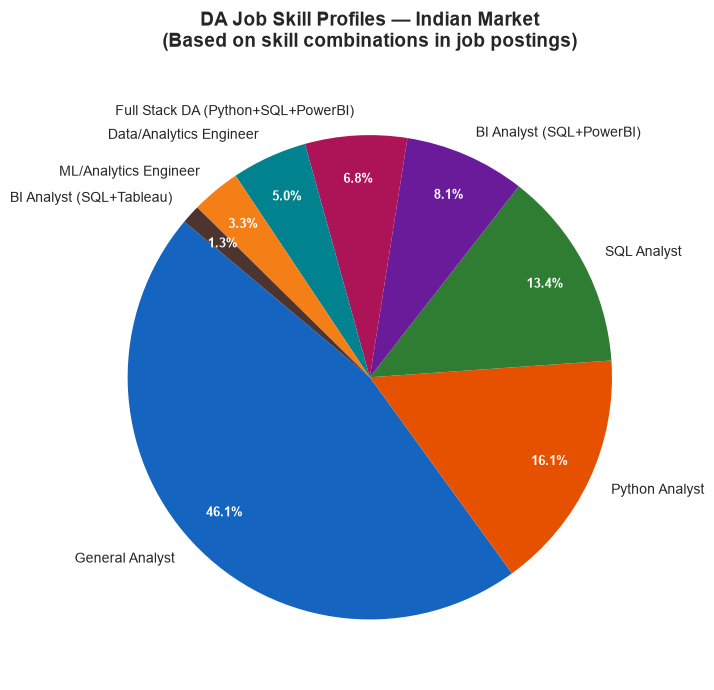

Chart saved.


In [19]:
# Cell 6 — Visualise skill profiles as pie chart
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1565C0', '#E65100', '#2E7D32', '#6A1B9A', 
          '#AD1457', '#00838F', '#F57F17', '#4E342E']

wedges, texts, autotexts = ax.pie(
    profile_counts.values,
    labels=profile_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(profile_counts)],
    startangle=140,
    pctdistance=0.82
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(
    'DA Job Skill Profiles — Indian Market\n'
    '(Based on skill combinations in job postings)',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('../data/skill_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

Experience Correlation Analysis

In [20]:
# Cell 1 — Skill demand vs experience required
# For each skill, what is the average minimum experience required?

skill_exp_data = []
for skill in skill_columns:
    skill_jobs = df[df[skill] == 1]['min_experience'].dropna()
    non_skill_jobs = df[df[skill] == 0]['min_experience'].dropna()
    
    if len(skill_jobs) > 5:  # only include if enough data points
        skill_exp_data.append({
            'skill': skill,
            'avg_exp_with_skill': round(skill_jobs.mean(), 1),
            'avg_exp_without_skill': round(non_skill_jobs.mean(), 1),
            'job_count': len(skill_jobs),
            'exp_premium': round(skill_jobs.mean() - non_skill_jobs.mean(), 1)
        })

exp_df = pd.DataFrame(skill_exp_data)
exp_df = exp_df.sort_values('avg_exp_with_skill', ascending=False)
print(exp_df.to_string(index=False))

             skill  avg_exp_with_skill  avg_exp_without_skill  job_count  exp_premium
             Azure                 5.0                    2.6          8          2.4
             Spark                 4.7                    2.6          6          2.1
               NLP                 3.7                    2.6          6          1.1
               ETL                 3.3                    2.6         19          0.7
               AWS                 3.3                    2.6          9          0.7
               GCP                 3.0                    2.6         14          0.4
               SAS                 2.9                    2.6         17          0.3
               Git                 2.8                    2.6          6          0.2
               SQL                 2.7                    2.6        143          0.2
            Python                 2.6                    2.6        124         -0.0
          Power BI                 2.4                

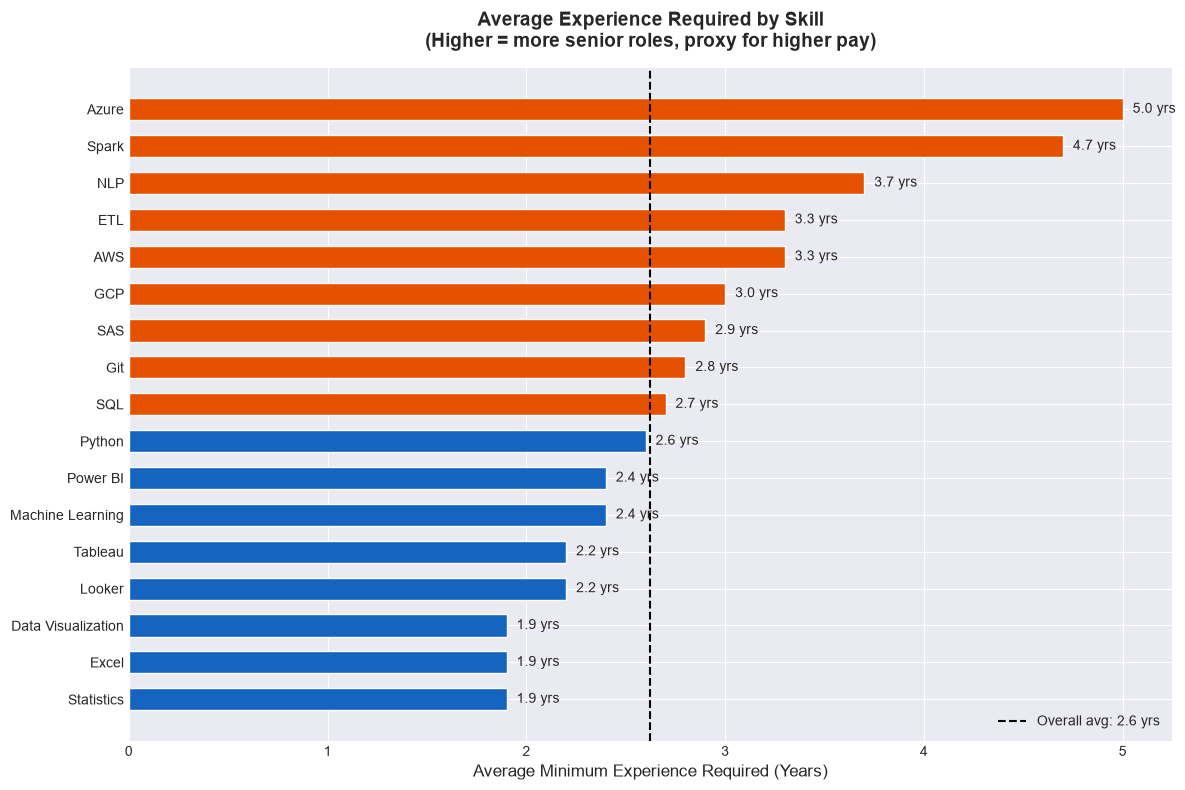

Chart saved.


In [21]:
# Cell 2 — Visualise average experience required per skill
fig, ax = plt.subplots(figsize=(12, 8))

exp_df_sorted = exp_df.sort_values('avg_exp_with_skill', ascending=True)

colors = ['#E65100' if x > 0 else '#1565C0' 
          for x in exp_df_sorted['exp_premium']]

bars = ax.barh(
    exp_df_sorted['skill'],
    exp_df_sorted['avg_exp_with_skill'],
    color=colors,
    height=0.6,
    edgecolor='white'
)

for bar, val in zip(bars, exp_df_sorted['avg_exp_with_skill']):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val} yrs',
        va='center',
        fontsize=10
    )

# Add overall average line
overall_avg = df['min_experience'].mean()
ax.axvline(x=overall_avg, color='black', linestyle='--', linewidth=1.5, 
           label=f'Overall avg: {overall_avg:.1f} yrs')

ax.set_xlabel('Average Minimum Experience Required (Years)', fontsize=12)
ax.set_title(
    'Average Experience Required by Skill\n'
    '(Higher = more senior roles, proxy for higher pay)',
    fontsize=14, fontweight='bold', pad=15
)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../data/skill_experience_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")